## Inspección visual de un producto

### Ficha PEAS
| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Matriz 5x5 de NumPy (`imagen`) con valores 0 (píxel normal) o 1 (píxel defectuoso) |
| **Acciones (A)** | "aprobar", "revisión manual", "rechazar" |
| **Entorno (E)** | Cámara industrial en línea de ensamblaje y control de calidad |
| **Objetivo** | Clasificar productos según su nivel de defecto en tiempo real |
| **Medida de Desempeño (P)** | Precisión en detección de fallas, reducción de falsos descartes y rendimiento |

### Justificación de las reglas
Un producto sin píxeles defectuosos (0 defectos) cumple totalmente los estándares de fabricación y se aprueba. Si presenta entre 1 y 3 píxeles defectuosos, la falla puede ser menor o tratarse de un error de lectura por polvo, por lo que se deriva a revisión manual para evitar descartes innecesarios. Si los defectos superan los 3 píxeles, la falla es estructural y el producto se rechaza automáticamente.

In [1]:
### Código
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    Retorna tupla: (accion, motivo)
    """
    defectos = np.sum(imagen == 1)
    
    if defectos == 0:
        return ("aprobar", "producto en perfecto estado (0 píxeles defectuosos)")
    elif defectos <= 3:
        return ("revisión manual", f"se detectaron {defectos} píxeles defectuosos (requiere inspección humana)")
    else:
        return ("rechazar", f"se detectaron {defectos} píxeles defectuosos (supera tolerancia permitida)")

             EVALUACIÓN DE CASOS DE INSPECCIÓN VISUAL                      
[Producto Perfecto] -> Acción: APROBAR
   Motivo: producto en perfecto estado (0 píxeles defectuosos)

[Caso Borde (3 Defectos)] -> Acción: REVISIÓN MANUAL
   Motivo: se detectaron 3 píxeles defectuosos (requiere inspección humana)

[Caso Rechazo (5 Defectos)] -> Acción: RECHAZAR
   Motivo: se detectaron 5 píxeles defectuosos (supera tolerancia permitida)

[Defecto Leve (1 Defecto)] -> Acción: REVISIÓN MANUAL
   Motivo: se detectaron 1 píxeles defectuosos (requiere inspección humana)



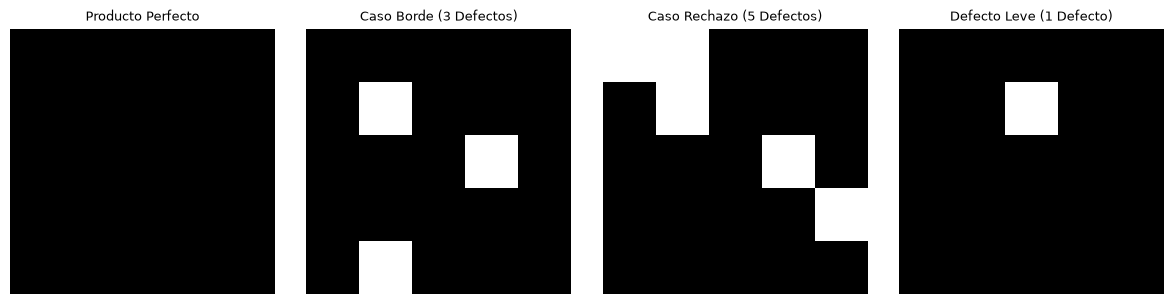

In [2]:
### Simulación y pruebas
import matplotlib.pyplot as plt

img_perfecta = np.zeros((5,5), dtype=int)

img_borde = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0]
])  # 3 defectos -> Revisión manual

img_rechazo = np.array([
    [1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0]
])  # 5 defectos -> Rechazar

img_leve = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])  # 1 defecto -> Revisión manual

casos_inspeccion = [
    ("Producto Perfecto", img_perfecta),
    ("Caso Borde (3 Defectos)", img_borde),
    ("Caso Rechazo (5 Defectos)", img_rechazo),
    ("Defecto Leve (1 Defecto)", img_leve)
]

print("==========================================================================")
print("             EVALUACIÓN DE CASOS DE INSPECCIÓN VISUAL                      ")
print("==========================================================================")
for titulo, img in casos_inspeccion:
    accion, motivo = agente_inspeccion(img)
    print(f"[{titulo}] -> Acción: {accion.upper()}")
    print(f"   Motivo: {motivo}\n")

# Visualización opcional
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (titulo, img) in zip(axes, casos_inspeccion):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(titulo, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()